In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

# Load data
file_path = "../datasets/apple_stock/AAPL.csv"
data = pd.read_csv(file_path)


In [2]:
# Convert date to datetime format and set it as the index
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Analyze and remove outliers using the interquartile range (IQR)
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
outliers = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)
cleaned_data = data[~outliers]


In [3]:
# Standardize data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cleaned_data)
scaled_data_df = pd.DataFrame(scaled_data, index=cleaned_data.index, columns=cleaned_data.columns)

# Add logarithmic returns and a 7-day moving average
positive_shift = scaled_data_df['Close'] + 1 - scaled_data_df['Close'].min()  # shift all values into the positive range
returns = np.log(positive_shift / positive_shift.shift(1))
scaled_data_df['Log_Returns'] = returns.replace([np.inf, -np.inf], np.nan).fillna(returns.mean())
scaled_data_df['SMA_7'] = scaled_data_df['Close'].rolling(window=7).mean()

# Remove rows with NaN values
final_data = scaled_data_df.dropna()


In [4]:
# Split data into train and test sets
X = final_data.drop('Close', axis=1)
y = final_data['Close']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and evaluate the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)  # Use root_mean_squared_error for RMSE


In [5]:
# Print results
print(f"Coefficient of Determination (R²): {r2}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Model coefficients: {model.coef_}")


Coefficient of Determination (R²): 0.9999640854828149
Root Mean Squared Error (RMSE): 0.0060671388573270485
Model coefficients: [-1.59747151e-01  4.10291829e-01  3.20571849e-01  4.08721156e-01
 -4.10345428e-04  4.74789315e-01  2.00480638e-02]


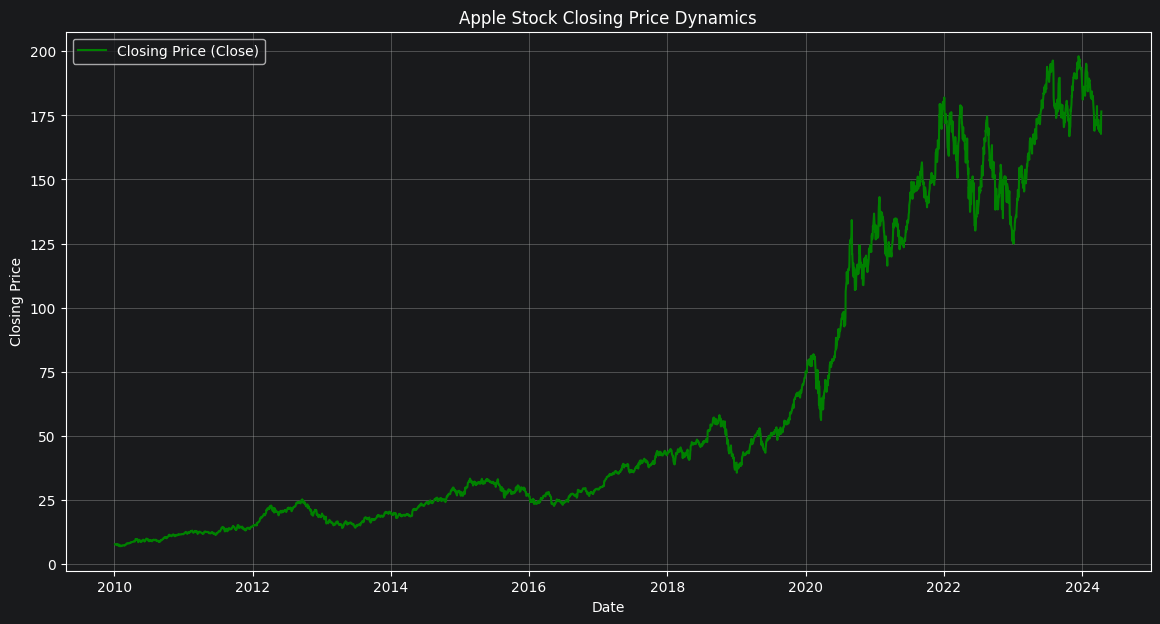

In [6]:
import matplotlib.pyplot as plt

# Plot the closing price
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Close'], label='Closing Price (Close)', color='green')

plt.title('Apple Stock Closing Price Dynamics')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)
plt.show()
